# interrupt와 Command로 구현하는 Human-in-the-loop

Human-In-The-Loop(HITL)은 Agent가 모든 판단을 자동으로 끝내지 않고, 

`사람의 확인이 필요한 지점에서 실행을 잠시 멈추는 설계`이다. 가격·재고처럼 모델이 확정할 수 없는 정보나 승인·결제처럼 위험한 작업에 사용한다.

이 실습에서는 `interrupt()`가 질문을 외부로 내보내고, 사람이 준 값을 `Command(resume=...)`으로 다시 넣는다. 

Checkpointer는 그 사이의 State와 실행 위치를 저장한다.

## 전체 흐름
![질문부터 interrupt 중단, 사람 입력과 재개를 거쳐 END에 도달하는 흐름](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/05_hitl_interrupt_resume_flow.svg)


1. 질문을 받은 `chatbot`이 `AIMessage.tool_calls`로 `human_assist` 호출을 요청한다.
2. `ToolNode`가 Tool을 실행하면 `interrupt({"query": query})`에서 멈춘다.
3. Checkpointer가 State를 저장하고, 호출자는 `__interrupt__`에서 요청 내용을 읽는다.
4. 사람의 답변을 같은 `thread_id`의 `Command(resume=...)`으로 전달한다.
5. 그 값이 `interrupt()`의 반환값이 되어 Tool 결과인 `ToolMessage`로 이어진다.
6. `chatbot`이 Tool 결과를 다시 읽고 최종 답변을 만들면 `END`에 도달한다.

> 이 흐름도는 [LangGraph 공식 Interrupts 문서](https://docs.langchain.com/oss/python/langgraph/interrupts)와 [Checkpointers 문서](https://docs.langchain.com/oss/python/langgraph/checkpointers)를 바탕으로 현재 실습 코드에 맞게 재구성한 이미지이다.


## 패키지 설치

LangGraph 실행기와 OpenAI·Tavily 연동 패키지를 준비한다. 패키지는 `중단 기능`만 제공하며, 

`interrupt payload`를 화면에 보여 주고 사람 답변을 받는 UI는 애플리케이션에서 따로 구현한다.


In [1]:
# %pip install -U langgraph langchain-openai langchain-tavily python-dotenv

## 모델과 검색 인증 준비

OpenAI는 `chatbot`의 판단과 답변에, Tavily는 검색 Tool에 사용한다. 필수 키는 `존재 여부만 검사`하고 값은 출력하지 않는다.

LangSmith는 실행 추적용 선택 기능이다. 추적 키가 없어도 HITL 그래프 자체는 실행할 수 있다.


In [2]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(
    usecwd=True,
)
load_dotenv(
    dotenv_path,
    override=False,
)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-hitl")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## 검색 Tool의 독립 실행

최신 웹 정보는 사람에게 묻기보다 Tavily 검색으로 처리할 수 있다. 그래프에 넣기 전에 Tool을 직접 호출하여 `질의 dict → 검색 → 결과 목록`의 기본 경로를 확인한다.


In [3]:
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from openai import OpenAI

tavily_tool = TavilySearch(max_result=3)
tavily_tool.invoke({"query": "리센느 파이리 닮은에 누구지?"})
# tavily_tool.invoke({"query": "LangGraph의 Human-in-the-Loop란 무엇인가?"})

# llm = ChatOpenAI(model=OPENAI_CHAT_MODEL, use_responses_api=True)

{'query': '리센느 파이리 닮은에 누구지?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.instagram.com/reel/DY1o9w0S4ci',
   'title': 'Instagram',
   'content': "allinone\\_mag\n\n리센느 멤버 원이가 ‘파이리 닮은꼴’로 온라인상에서 화제를 모은 가운데, 이 관심이 팀의 포켓몬스터 주제가 리메이크 소식으로 이어지며 눈길을 끌고 있습니다.  \n  \n팬들 사이에서 원이의 밝은 이미지와 표정이 포켓몬스터 캐릭터 파이리를 떠올리게 한다는 반응이 확산됐고, 멤버들 역시 관련 밈을 자연스럽게 받아들이며 리센느만의 친근한 매력을 보여줬습니다.  \n  \n이후 리센느가 포켓몬스터 1기 엔딩곡 ‘포켓몬 우리는 모두 친구’ 스페셜 리메이크 음원에 참여하게 되면서, 원이의 닮은꼴 화제는 단순한 팬 반응을 넘어 팀의 새로운 콘텐츠 이슈로 확장됐습니다.  \n  \n📍리센느(@rescene\\_official)  \n  \n🎥 YouTube 'RESCENE'  \n  \n#포켓몬스터 #리센느 #rescene #kpop #fyp\n\ndjiqkimeukd's profile picture\n\ndjiqkimeukd\n\n❤️❤️❤️❤️❤️❤️❤️❤️❤️거제야호 파이리 오이쉬 [...] Reply\n\ndjiqkimeukd's profile picture\n\ndjiqkimeukd\n\nReply\n\nkimdong_glad's profile picture\n\nkimdong\\_glad\n\n거제갈때 파이리 들고 다녀야지😍😍\n\nReply\n\ndwow1910's profile picture\n\ndwow1910\n\nReply\n\ni_enjoy_my_life_84.2.27's profile picture\n\ni\\_enjoy\\_my\\_life\\_84.2.27\n\n❤

## interrupt를 호출하는 사람 요청 Tool

`human_assist`는 모델이 확정할 수 없는 질문을 사람에게 전달하는 Tool이다. 여기서는 `나가는 값`과 `들어오는 값`을 구분해야 한다.

- `interrupt({"query": query})`: 호출자에게 내보내는 `중단 요청 payload`이다.
- `Command(resume={"data": ...})`: 사람이 그래프에 다시 넣는 `재개 값`이다.
- `human_response["data"]`: 재개 값에서 꺼낸 문자열이며 Tool 실행 결과가 된다.

즉 `interrupt()` 호출은 한 줄이지만, 처음에는 실행을 멈추고 재개 후에는 `resume` 값을 반환하는 두 역할을 한다.

### 동적 interrupt와 정적 breakpoint의 차이

현재 실습의 `interrupt()`는 `human_assist`가 실제 실행될 때만 멈추는 `동적 interrupt`이다. 반면 `compile(interrupt_before=["tools"])`처럼 Node 이름을 지정하는 방식은 해당 Node 실행 전마다 멈추는 `정적 breakpoint`이다. 이번에는 사람에게 질문을 보내고 그 답을 Tool 결과로 받아야 하므로 동적 interrupt를 사용한다.


In [4]:
from langchain_core.tools import tool
from langgraph.types import interrupt

# llm = ChatOpenAI(model=OPENAI_CHAT_MODEL, use_responses_api=True)

# # llm 이 툴을 호출할수있게 bind함
# tools = [tavily_tool]
# llm_with_tools = llm.bind_tools(tools)


@tool  # 파이썬 함수를 LLM과 Tool Node가 호출할 수 있는 Tool 객체로 변환
def human_assist(query: str) -> str:
    """자동으로 확정할 수 없는 문의를 사람에게 전달하고 답변을 반환한다"""
    # interrupt(payload) :
    # - payload를 호출자에게 노출하고 현재 graph 실행을 중단
    # - payload : 전달 되는 실제 데이터의 본문
    #           + payload는 외부 UI/API가 인식할 수 있다록 json 직렬화가 가능한 값이어야 한다
    human_response = interrupt(
        {
            "query": query,
        }
    )
    # --------- 여기서 멈춤 --------------
    # 흐름이 재개될 때 Command(resume={"data":"답변"})의 추가되어 동작한다
    return human_response["data"]  # == 사람의 답변

## 두 Tool을 Chat Model에 바인딩하기

`tools`는 실제로 실행할 수 있는 `Tool 객체 목록`이다. 반면 `AIMessage.tool_calls`는 모델이 “이 Tool을 이 인자로 호출해 달라”고 만든 `호출 요청 목록`이다.

`bind_tools()`는 Tool의 이름과 입력 스키마를 모델에 알려 줄 뿐 실행하지 않는다. 실제 호출은 뒤의 `ToolNode(tools)`가 담당한다.


In [5]:
from langchain_openai import ChatOpenAI
from pprint import pprint
llm = ChatOpenAI(
    model=OPENAI_CHAT_MODEL,
    use_responses_api=True,
)
tools = [tavily_tool, human_assist]
# 사용자 질문을 분석하여 필요시 tools 목록에 존재하는
# 도구(tool)을 알아서 호출 -> tool_calls 형태
llm_with_tools = llm.bind_tools(tools)


## 중단과 재개를 완성할 다섯 구성 요소

여기까지 만든 `llm_with_tools`는 검색 또는 사람 확인을 `요청할 수 있는 모델`이다. 그러나 Tool 요청만으로는 message 이력 보존, Tool 실행, 중단 위치 저장과 재개가 자동으로 완성되지 않는다.

```text
State(messages)
  ↓
chatbot ── tool_calls 없음 ──→ END
  ↓ tool_calls 있음
ToolNode → human_assist → interrupt(payload)
                           ↓ Checkpointer가 저장
Command(resume=value) → interrupt() 반환 → ToolMessage → chatbot → END
```

### 1. message 이력을 보관하는 State

`State.messages`는 중단 전후에 이어서 사용할 대화와 Tool 실행 기록이다.

- 입력: 기존 `messages`와 각 Node가 반환한 새 message이다.
- 변환: `add_messages` reducer가 새 message를 기존 이력 뒤에 합친다.
- 출력: `HumanMessage`·`AIMessage`·`ToolMessage`가 누적된 State이다.
- 다음 사용처: 다음 Node가 읽고 Checkpointer가 중단 위치와 함께 저장한다.

### 2. 다음 행동을 만드는 chatbot Node

`chatbot`은 누적된 대화를 읽어 모델의 다음 행동을 만든다.

- 입력: 현재 State의 전체 `messages`이다.
- 변환: `llm_with_tools`가 일반 답변 또는 Tool 요청을 결정한다.
- 출력: 새 `AIMessage` 하나를 담은 State update이다.
- 다음 사용처: `add_messages`가 State에 합치고 `tools_condition`이 다음 경로를 판단한다.

### 3. Tool 요청을 실행하는 ToolNode

`ToolNode(tools)`는 모델이 만든 요청을 실제 Python Tool 실행으로 바꾼다.

- 입력: 최신 `AIMessage.tool_calls`의 Tool 이름·인자·호출 ID이다.
- 변환: 요청한 `tavily_tool` 또는 `human_assist`를 실행한다.
- 출력: 실행 결과와 호출 ID가 연결된 `ToolMessage`이다.
- 다음 사용처: State에 합쳐진 뒤 `tools → chatbot` Edge를 따라 모델로 돌아간다.

### 4. Tool 실행과 종료를 고르는 route function

`tools_condition`은 Conditional Edge 자체가 아니라 다음 목적지 label을 반환하는 함수이다.

- 입력: `chatbot`이 방금 만든 최신 `AIMessage`이다.
- 변환: `tool_calls` 목록이 비어 있는지 확인한다.
- 출력: 요청이 있으면 `"tools"`, 없으면 `END`를 반환한다.
- 다음 사용처: `add_conditional_edges()`가 반환값을 실제 목적지와 연결한다.

### 5. 중단 위치를 저장하고 찾는 Checkpointer

`InMemorySaver`는 interrupt 전후의 State와 실행 위치를 같은 thread에 보관한다.

- 입력: 실행 시 전달한 `thread_id`, State와 현재 실행 위치이다.
- 변환: 실행 단계별 값을 해당 thread의 checkpoint로 저장한다.
- 출력: `get_state()`로 조회하고 재개할 수 있는 `StateSnapshot`이다.
- 다음 사용처: 같은 `thread_id`의 `Command(resume=...)`가 중단된 실행을 찾는다.


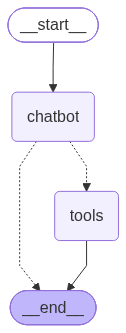

In [6]:
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


# 1. State Schema 설정
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


# chatbot note 함수 정의
def chatbot(state: State) -> dict:

    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}


def build_graph():
    # 그래피 빌더 생성
    workflow = StateGraph(State)
    # 노드 등록
    workflow.add_node("chatbot", chatbot)
    workflow.add_node("tools", ToolNode(tools))
    
     # 시작 지점
    workflow.add_edge(START, "chatbot")
    # 분기 조건
    workflow.add_conditional_edges(
        # 분기할 노드
        "chatbot",
        # chatbot의 AIMessage에 tool_calls가 있으면 'tools'
        # . 없으면 END
        tools_condition,
    )

    return workflow.compile(checkpointer=InMemorySaver())

graph = build_graph()
display(graph)

## 실행 준비: thread_id로 checkpoint를 찾는 함수 만들기

`graph.get_state(config)`는 `configurable.thread_id`에 대응하는 최신 checkpoint를 `StateSnapshot`으로 반환한다.<br>
 이 `thread_id`는 사용자 이름이 아니라 `한 실행 이력을 구분하는 key`이며, 최초 실행·상태 조회·재개에 같은 값을 사용해야 한다.

- `snapshot.values`: 그 시점의 State 값이며 여기서는 `messages`를 포함한다.
- `snapshot.next`: 다음에 실행할 Node 이름의 tuple이다. `()`이면 대기 Node 없이 완료된 상태이다.
- `snapshot.tasks`: pending task의 상세 기록이다. Node 이름·오류·interrupt 정보를 확인할 때 사용한다.

아래 셀은 `config`와 조회 함수를 만든 뒤 아직 실행하지 않은 thread를 한 번 조회한다. 입력은 `graph`와 `config`, 

출력은 저장된 messages와 다음 Node이며, 같은 함수는 중단 전후 상태 비교에 계속 사용된다.


In [7]:
from pprint import pprint
from langchain_core.runnables import RunnableConfig

# 1. 최초 실행/ snapshot 조회 / interrupt 재개 시
# 함께 전달할 설정
# config: RunnableConfig = {"configurable": {"thread_id": "cake-customer-1"}}
config = RunnableConfig(configurable={"thread_id": "cake-customer-1"})


# 2. 입력 graph·config → StateSnapshot 조회 → messages·next 출력 함수
def print_snapshot(graph, config):
    snapshot = graph.get_state(
        config,  #
    )
    print("Messages:")
    pprint(
        snapshot.values.get(
            "messages",
            [],
        )
    )
    print("Next:", snapshot.next)


# 3. print_snapshot(graph, config): 새 thread의 초기 저장 상태 확인
print_snapshot(
    graph,
    config,
)

Messages:
[]
Next: ()


## 실행 경로 A: interrupt 없이 END까지 진행하기

먼저 사람 확인이 필요 없는 질문을 실행한다. 모델이 `tool_calls`를 만들지 않으면 `tools_condition`이 곧바로 `END`를 선택하므로 `interrupt()`는 호출되지 않는다.

입력 질문은 `chatbot`에서 최종 `AIMessage`로 바뀌고, 반환된 State의 마지막 message를 출력한다. 

이 결과를 뒤의 중단 경로와 비교하면 HITL이 `모든 질문을 멈추는 기능이 아니라 필요한 분기만 멈추는 기능`임을 확인할 수 있다.


In [8]:

user_input = "Agent LangGraph 개발 특징이 무엇이 있을꺼?"

# input_state: State = {
#     "messages": [
#         HumanMessage(content=user_input)
#     ]
# }

response = graph.invoke(
    {
        "messages": [
            # HumanMessage로 자동 변환됨
            ("human", user_input)
        ]
    },
    config=config,
)

pprint(response["messages"][-1].content)


[{'content': [],
  'encrypted_content': 'gAAAAABqhAzuOK5wfUrrhozuKiorC61w0f1lPH0bPfzWM6Ille1Viv4yu_YhD7DLFWHuloIldrSGCqhalqzGalK9-mgNQfg_Vf3k6KNZrh6VfDkmRc8rQvZUZb-0hbzG4TQSR_xLYYLF4Dch5CCyC0ikHTQrtN6gHLcMBHMg_TctXvhI2_CjlyfwCese08Ynh6C_ujxrOHVdCMOQJ7RhQtbElj2qL8jEbWFg1vN9BSqpvic3-1ky-mWJIceJRour981zKY7clFidEeg9cRncaNtxl7Mfy0rk6lsiIqKmQI3J2UCKzAopUxpEuBNHOsmIJKbML7m9tC0kM7NJDAO0AI8QbaAtHft3XLJk3a8EgdInKaK4WsfGMhEvdnzJwOEi7aY9rUsPpzQXYWdXSOvPhLxGa99w9uD7N0QQV8_qEaALsPPl_kv2rpqjQRtMKUcro1ckBblnzOVYdv78pU0HVJWebUdt39E2YoGvwZjhzNMNaMwVaJ4S3mYYXwePi36duMXHUk4bCl9T3kbIN3OjqmkFwrSxEp-URgaaTlfIO6C2XAIcr39iUIWqaILP7OYchFnYOX7sdyncOAK3g62_WAD9cVH9NgMDwWr2X260uCrm9wcmdjsC7BixrT5sbrVcN5oDt-AJOX14OLiYGeyQVwDr4voesh20uZ9TPdsxmbLA2AXd2trL54C3RrCCmMkE1vkpWtGinR52z_3-AQ5HEAs9TWm-Lu-PDinukNNEvhxpr3PnAXeZnc8j8a3tx6GepRIRJpGVJYErpidvEdHA9qylKo77oidaW4FR8ms-MAXghrD0OtKKeM8dtJHnpClHL8Bi2usqcpuIihOba8AMyOL39Be3vzor--ehA5hjhZ7vZiNagO8SFlBBZdotxnmwNyJtjkoCODvOM3Z2Q5lPsHWbOyk6vruoeAOZldmPbmH_olJeOJCfyNHX4dMxXDC

### 실행 결과 A: 완료된 checkpoint 확인하기

같은 `thread_id`의 최신 snapshot을 다시 읽는다. messages가 남아 있어도 `next=()`이면 대기 중인 Node가 없으므로 실행은 완료된 상태이다.


In [9]:
print_snapshot(
  graph,
  config
)

Messages:
[HumanMessage(content='Agent LangGraph 개발 특징이 무엇이 있을꺼?', additional_kwargs={}, response_metadata={}, id='902c152c-b1df-4870-9f80-bab0f9f4fe3b'),
 AIMessage(content=[{'id': 'rs_0651f195e8a4b234006a840cdd06e087d0bbe591fc9b9cd4ac', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqhAzuOK5wfUrrhozuKiorC61w0f1lPH0bPfzWM6Ille1Viv4yu_YhD7DLFWHuloIldrSGCqhalqzGalK9-mgNQfg_Vf3k6KNZrh6VfDkmRc8rQvZUZb-0hbzG4TQSR_xLYYLF4Dch5CCyC0ikHTQrtN6gHLcMBHMg_TctXvhI2_CjlyfwCese08Ynh6C_ujxrOHVdCMOQJ7RhQtbElj2qL8jEbWFg1vN9BSqpvic3-1ky-mWJIceJRour981zKY7clFidEeg9cRncaNtxl7Mfy0rk6lsiIqKmQI3J2UCKzAopUxpEuBNHOsmIJKbML7m9tC0kM7NJDAO0AI8QbaAtHft3XLJk3a8EgdInKaK4WsfGMhEvdnzJwOEi7aY9rUsPpzQXYWdXSOvPhLxGa99w9uD7N0QQV8_qEaALsPPl_kv2rpqjQRtMKUcro1ckBblnzOVYdv78pU0HVJWebUdt39E2YoGvwZjhzNMNaMwVaJ4S3mYYXwePi36duMXHUk4bCl9T3kbIN3OjqmkFwrSxEp-URgaaTlfIO6C2XAIcr39iUIWqaILP7OYchFnYOX7sdyncOAK3g62_WAD9cVH9NgMDwWr2X260uCrm9wcmdjsC7BixrT5sbrVcN5oDt-AJOX14OLiYGeyQVwDr4voesh20uZ9TPdsxmbLA2AXd

## 실행 경로 B: 사람 확인용 thread 준비하기

재고와 가격은 모델이 임의로 확정하면 안 된다. Prompt에 “추측하지 말고 `human_assist`를 사용한다”는 정책을 넣어 사람 확인 경로를 유도한다.

앞의 일반 질문과 checkpoint가 섞이지 않도록 `새 graph와 새 `thread_id``를 사용한다. 입력 문의는 매장 정책과 결합된 Prompt가 되고, 다음 셀의 첫 `invoke()`에서 `chatbot`에 전달된다.


In [10]:
graph = build_graph()

config: RunnableConfig = {
    "configurable": {
        "thread_id": "cake-order-approval-1"
    }
}

def get_human_prompt(user_input: str) -> str:
    return f"""
당신은 프리미엄 케이크 매장의 안내 Agent이다.
- 운영 시간: 매일 09:00~21:00
- 주요 메뉴: 생크림, 초코, 치즈와 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 확정할 수 없는 구매 가능 여부나 가격은 추측하지 말고 human_assist Tool을 사용한다.

사용자 문의:
{user_input}

답변은 한 문단 이내로 작성하고, 사람 답변을 받았다면 그 내용만 근거로 안내한다.
"""

prompt = get_human_prompt("4호 케이크가 홈페이지에서 구매가 되지 않는데, 구매 가능한지 직원에게 확인해줘")

print(prompt)




당신은 프리미엄 케이크 매장의 안내 Agent이다.
- 운영 시간: 매일 09:00~21:00
- 주요 메뉴: 생크림, 초코, 치즈와 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 확정할 수 없는 구매 가능 여부나 가격은 추측하지 말고 human_assist Tool을 사용한다.

사용자 문의:
4호 케이크가 홈페이지에서 구매가 되지 않는데, 구매 가능한지 직원에게 확인해줘

답변은 한 문단 이내로 작성하고, 사람 답변을 받았다면 그 내용만 근거로 안내한다.



### 1단계: interrupt payload를 받고 멈추기

* payload : 호출시 응답되는 본문

이번 `invoke()`는 최종 답변을 받기 위한 호출이 아니라 `사람에게 보여 줄 중단 요청을 얻는 호출`이다.

입력 Prompt는 `chatbot → AIMessage.tool_calls → ToolNode → human_assist → interrupt` 순서로 전달된다. `interrupt()`에서 실행이 멈추면 호출자는 반환 dict의 `__interrupt__`에서 payload를 읽는다. 이 payload는 사람의 답변이 아니라 `사람에게 전달할 질문`이다.


In [11]:
response = graph.invoke({"messages": [("human", prompt)]}, config=config)

# interrupt 확인
print(
  # interrupt 상태면 dict의 value 반환 
  #  __interrupt__ : key
  response.get("__interrupt__"))

[Interrupt(value={'query': '홈페이지에서 구매가 되지 않는 4호 케이크가 현재 구매 가능한지 직원에게 확인해 주세요.'}, id='35d3d00c3afe2ae4b9625a8db535605f')]


### 2단계: 중단 checkpoint와 대기 Node 확인하기

중단 직후 Checkpointer는 messages뿐 아니라 아직 끝나지 않은 실행도 checkpoint에 보존한다.

- `snapshot.tasks`: 중단된 Tool 실행을 포함한 pending task의 상세 정보이다.
- `snapshot.next`: 다음에 이어서 실행할 Node 이름만 담은 간단한 tuple이다.

아래 helper는 `tasks`를 직접 출력하지 않고 `next`만 보여 준다. 따라서 `next`가 비어 있지 않으면 `실행이 END가 아니라 특정 Node에서 대기 중`이라고 해석한다.


In [12]:
print_snapshot(graph,
  config,)

Messages:
[HumanMessage(content='\n당신은 프리미엄 케이크 매장의 안내 Agent이다.\n- 운영 시간: 매일 09:00~21:00\n- 주요 메뉴: 생크림, 초코, 치즈와 시즌 한정 케이크\n- 매장 위치: 서울 강남구 신사동 123-45\n- 확정할 수 없는 구매 가능 여부나 가격은 추측하지 말고 human_assist Tool을 사용한다.\n\n사용자 문의:\n4호 케이크가 홈페이지에서 구매가 되지 않는데, 구매 가능한지 직원에게 확인해줘\n\n답변은 한 문단 이내로 작성하고, 사람 답변을 받았다면 그 내용만 근거로 안내한다.\n', additional_kwargs={}, response_metadata={}, id='435d62f9-b864-455e-8420-b06e7d663796'),
 AIMessage(content=[{'id': 'rs_0b4e67926a0f59b1006a840cf0827487d0bcd95afc4f3e41fb', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqhAzx8pVhJEBJdShsukSI7OgxzDeXxu2M2pl8Ih69GLlz8UuzNSgznk4-pBHcx41H4Hvz23-K42qJgECdxmTOAJKGqsoTmpzidX3OePdSPQHeglc4LeU-45d3PM5Ph_DK515nSHU3gIpITU6i7PH2hLVrKsFyfpJdaJ3lxYdcMo33GXUjjltC4BkWKXoEI6tnLodWYNnM9RcujvZsXk1TBvN9iOkKZjBP4fTu_-5pVK4xt305johHlgvkqAlkI74D-LpDqfPl1XoTMaLdRRKn9Rsip_TLjn5__tL2bw1L2mHLS1GMpxezrCnfl7Sojvrg3fjU5o7wz1DOWRp83SN6r4AssxrgzI92jzxF9Uay6QHrjd1wy7mdNaMwuxz8X4LNqMNJq-myLs1YqWd-DM2l-tPRxQtQDnj6KutgB8alKr6

### 3단계: 사람의 검토 결과로 interrupt 재개하기

아래 `human_response` 문자열은 실제 서비스에서 담당자가 UI로 입력한 `사람의 검토 결과`를 수업용으로 대신한 값이다. 

이 값을 `Command(resume={"data": ...})`에 담아 `같은 `thread_id``로 전달한다.

`resume`은 새 사용자 질문을 추가하지 않고 중단된 `interrupt()`의 반환값을 공급한다. 

`Command`의 `update`는 State 값을 갱신할 때 사용하는 선택지이지만, 현재 `human_assist`는 `interrupt()`의 반환값을 기다리므로 `resume`이 필요하다.

재개 시 `interrupt()`가 있는 Node는 처음부터 다시 실행될 수 있다. 

따라서 interrupt 앞에서 파일 저장·결제 같은 side effect를 수행한다면 여러 번 실행되어도 결과가 안전한 멱등 작업으로 설계해야 한다.

값의 흐름은 `resume dict → interrupt() 반환값 → human_assist 반환 문자열 → ToolMessage → chatbot 재판단 → END`이다.


In [13]:
from langgraph.types import Command

# 1. 사람의 응답(str)
human_response = (
    "죄송합니다, 홈페이지 기능이 일시적인 오류로 인해 주문이 되지 않았습니다"
    "현재 복구되어 4호 케이크 구매 가능합니다"
    "가격은 50,000원 입니다"
)

# 2. Command(resume=...) 형태로 변경
resume_command = Command(resume={"data": human_response})

# 3. graph에 invoke
response = graph.invoke(
    # 새 질문 아니고 
    # interrupt에 등록할 커맨드
    resume_command,
    config=config,
)

print(response["messages"][-1].content)

죄송합니다, 홈페이지 기능이 일시적인 오류로 인해 주문이 되지 않았습니다현재 복구되어 4호 케이크 구매 가능합니다가격은 50,000원 입니다


### 4단계: END와 저장된 message 확인하기

마지막으로 같은 thread의 최신 checkpoint를 확인한다. messages에는 이전의 `AIMessage.tool_calls`, 사람 답변을 담은 `ToolMessage`, 이를 반영한 최종 `AIMessage`가 함께 남는다.

`next=()`이면 저장된 대화 State는 존재하지만 pending task는 없으며, 그래프가 `END`까지 완료되었다고 해석한다.


In [14]:
print_snapshot(graph, config)

Messages:
[HumanMessage(content='\n당신은 프리미엄 케이크 매장의 안내 Agent이다.\n- 운영 시간: 매일 09:00~21:00\n- 주요 메뉴: 생크림, 초코, 치즈와 시즌 한정 케이크\n- 매장 위치: 서울 강남구 신사동 123-45\n- 확정할 수 없는 구매 가능 여부나 가격은 추측하지 말고 human_assist Tool을 사용한다.\n\n사용자 문의:\n4호 케이크가 홈페이지에서 구매가 되지 않는데, 구매 가능한지 직원에게 확인해줘\n\n답변은 한 문단 이내로 작성하고, 사람 답변을 받았다면 그 내용만 근거로 안내한다.\n', additional_kwargs={}, response_metadata={}, id='435d62f9-b864-455e-8420-b06e7d663796'),
 AIMessage(content=[{'id': 'rs_0b4e67926a0f59b1006a840cf0827487d0bcd95afc4f3e41fb', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqhAzx8pVhJEBJdShsukSI7OgxzDeXxu2M2pl8Ih69GLlz8UuzNSgznk4-pBHcx41H4Hvz23-K42qJgECdxmTOAJKGqsoTmpzidX3OePdSPQHeglc4LeU-45d3PM5Ph_DK515nSHU3gIpITU6i7PH2hLVrKsFyfpJdaJ3lxYdcMo33GXUjjltC4BkWKXoEI6tnLodWYNnM9RcujvZsXk1TBvN9iOkKZjBP4fTu_-5pVK4xt305johHlgvkqAlkI74D-LpDqfPl1XoTMaLdRRKn9Rsip_TLjn5__tL2bw1L2mHLS1GMpxezrCnfl7Sojvrg3fjU5o7wz1DOWRp83SN6r4AssxrgzI92jzxF9Uay6QHrjd1wy7mdNaMwuxz8X4LNqMNJq-myLs1YqWd-DM2l-tPRxQtQDnj6KutgB8alKr6